# Student Notebook — Full Pipeline (one file, one CONFIG cell)

This single notebook runs the entire four-layer pipeline:

1. **Train** a model on dialogue features
2. **Calibrate** its probability outputs
3. **Decide** Greenlight / Pass / Refer using a cost matrix
4. **Explain** with SHAP
5. **Evaluate** on the held-out test set (optional toggle)

Edit the CONFIG cell once, run all cells in order, copy the
headline numbers into the team comparison table.

## What to run first

1. From the project root: ``pip install -r requirements.txt``
2. Confirm ``data/processed/features.parquet`` exists (it
   does in this checkout).
3. Open this notebook in Jupyter or VS Code and run all cells.

## Team workflow

Each teammate edits the CONFIG cell to set:

- a unique ``run_name`` (so artifacts don't clobber each other)
- their chosen ``model_family`` (test logistic vs random_forest
  vs xgboost vs svm_rbf — see the bake-off table at the bottom)
- any of the three improvement toggles
  (``use_grid_search`` / ``use_repeated_cv`` / ``use_class_balance``)

Then everyone runs the notebook top-to-bottom and shares results.

## The test-set rule

``EVALUATE_ON_TEST`` at the bottom of CONFIG defaults to
``False``. **Leave it False** while iterating on model choice.
Only flip to ``True`` once for the final, frozen run that
goes in the report.

## CONFIG — edit me

Every knob the team will play with lives in this one cell.
Change values, re-run all cells.

In [20]:
CONFIG = {
    # YOUR run_name — unique label, e.g. "alice_xgboost".
    # Each run lands in data/processed/student/<run_name>/.
    "run_name": "team_baseline_rf",

    # Target. Headline = roi_gt_2 (was the film net-profitable?).
    "target":       "roi_gt_1",            # "roi_gt_2" | "roi_gt_1"
    "model_family": "logistic",       # "logistic" | "random_forest" | "xgboost" | "svm_rbf"
    "feature_set":  "all",                 # "all" | "structural" | "topic" | "embedding" | "network"

    # ---- Improvement toggles ----
    # All three on by default. Flip to False to ablate.
    "use_grid_search":   True,             # tune hyperparameters via GridSearchCV
    "use_repeated_cv":   True,             # 5 folds x 3 repeats (15 fold values)
    "use_class_balance": True,             # class_weight='balanced' / scale_pos_weight

    # ---- Calibration ----
    "calibration_method": "isotonic",      # "sigmoid" | "isotonic"

    # ---- Cost matrix (Greenlight / Pass / Refer) ----
    "flop_cost":   50_000_000,             # $50M  - greenlight a flop
    "miss_cost":  100_000_000,             # $100M - pass on a hit
    "refer_cost":      5_000,              # $5K   - human reader pass

    # ---- SHAP ----
    "shap_top_k_global":   20,             # top features in the global plot
    "shap_top_k_per_film": 5,              # top contributors per film
    "shap_example_imdb_id": "auto",        # "auto" picks highest-prob film

    # ---- THE TEST-SET TOGGLE ----
    # Leave False while iterating. Flip to True ONCE for the
    # final report number; you only get to run on test once.
    "EVALUATE_ON_TEST": False,

    # CV / random seed
    "n_splits":   5,
    "n_repeats":  3,
    "random_seed": 42,
}

## Setup — paths and imports

Path-finder walks up the filesystem to locate the project
root by looking for ``docs/PROJECT_CONTEXT.md``. Works whether
you launch Jupyter from the project root or from the
``notebooks/student/`` directory.

In [21]:
from pathlib import Path

def _find_project_root() -> Path:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "docs" / "PROJECT_CONTEXT.md").is_file():
            return cand
    raise RuntimeError(f"Could not locate project root from {Path.cwd()!s}")

PROJECT_ROOT = _find_project_root()
DATA = PROJECT_ROOT / "data" / "processed"
STUDENT = DATA / "student" / CONFIG["run_name"]
STUDENT.mkdir(parents=True, exist_ok=True)
print(f"Project root:  {PROJECT_ROOT}")
print(f"Run name:      {CONFIG['run_name']!r}")
print(f"Artifacts go:  {STUDENT.relative_to(PROJECT_ROOT)}")

Project root:  /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project
Run name:      'team_baseline_rf'
Artifacts go:  data/processed/student/team_baseline_rf


In [22]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, f1_score,
    log_loss, roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold, cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

# 1. Load data

We use the prebuilt 127-feature matrix from Phase 3 plus the
train/cal/test split assignment. The test split is held out
until the final section.

In [23]:
feat = pd.read_parquet(DATA / "features.parquet").reset_index()
master = pd.read_parquet(DATA / "films_joined.parquet")
print(f"Total films: {len(feat)} | split breakdown: {feat['split'].value_counts().to_dict()}")

# Train + cal pool (everything except the test split).
df = feat[feat["split"].isin(["train", "cal"])].reset_index(drop=True)
non_feat = {"imdb_id", "split", "log_roi", "roi_gt_1", "roi_gt_2"}
all_cols = [c for c in df.columns if c not in non_feat]
groups = {
    "all":        all_cols,
    "structural": [c for c in all_cols if c.startswith(("log_", "n_", "dialogue_to_", "release_year", "log_runtime", "genre_"))],
    "topic":      [c for c in all_cols if c.startswith("topic_")],
    "embedding":  [c for c in all_cols if c.startswith("embed_pc_")],
    "network":    [c for c in all_cols if c.startswith("network_")],
}
feat_cols = groups[CONFIG["feature_set"]]
target_col = CONFIG["target"]
X = df[feat_cols].fillna(0).values
y = df[target_col].astype(int).values

train_mask = (df["split"] == "train").values
cal_mask   = (df["split"] == "cal").values
X_train, y_train = X[train_mask], y[train_mask]
X_cal,   y_cal   = X[cal_mask],   y[cal_mask]
ids_cal = df.loc[cal_mask, "imdb_id"].astype(str).tolist()

print(f"Feature set {CONFIG['feature_set']!r}: {len(feat_cols)} columns")
print(f"Train: {len(X_train)} films, positive rate {y_train.mean():.3f}")
print(f"Cal:   {len(X_cal)} films, positive rate {y_cal.mean():.3f}")

Total films: 1713 | split breakdown: {'train': 1199, 'cal': 257, 'test': 257}
Feature set 'all': 127 columns
Train: 1199 films, positive rate 0.809
Cal:   257 films, positive rate 0.794


# 2. Train and tune the model (Layer 1)

Three improvement toggles bundled here:

1. **`use_class_balance`** — `class_weight='balanced'` or
   XGBoost's `scale_pos_weight = n_neg / n_pos`. Compensates
   the 60/40 imbalance on roi_gt_2.
2. **`use_repeated_cv`** — 5 folds × 3 repeats = 15 fold
   values per CV cell, instead of 5. Tighter confidence
   intervals.
3. **`use_grid_search`** — small per-family grid
   (3-18 candidates). Often the biggest single lift.

In [24]:
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / max(n_pos, 1)
print(f"Class balance: {n_neg} negative, {n_pos} positive  ->  scale_pos_weight = {scale_pos_weight:.3f}")

def build_model(family, seed=42, balance=False):
    cw = "balanced" if balance else None
    if family == "logistic":
        clf = LogisticRegression(max_iter=2000, C=1.0, class_weight=cw, random_state=seed)
    elif family == "random_forest":
        clf = RandomForestClassifier(n_estimators=300, max_depth=None,
                                      min_samples_leaf=2, class_weight=cw,
                                      random_state=seed, n_jobs=-1)
    elif family == "xgboost":
        if not HAS_XGB:
            raise RuntimeError("xgboost not installed. pip install xgboost")
        spw = scale_pos_weight if balance else 1.0
        clf = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            scale_pos_weight=spw, eval_metric="logloss",
                            random_state=seed, n_jobs=-1)
    elif family == "svm_rbf":
        clf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
                  class_weight=cw, random_state=seed)
    else:
        raise ValueError(f"Unknown model_family: {family!r}")
    return Pipeline([("scaler", StandardScaler(with_mean=False)), ("model", clf)])

base_model = build_model(CONFIG["model_family"], seed=CONFIG["random_seed"],
                          balance=CONFIG["use_class_balance"])
print(f"Built {CONFIG['model_family']!r} | class_balance={CONFIG['use_class_balance']}")

Class balance: 229 negative, 970 positive  ->  scale_pos_weight = 0.236
Built 'logistic' | class_balance=True


In [25]:
# CV scheme.
if CONFIG["use_repeated_cv"]:
    cv = RepeatedStratifiedKFold(n_splits=CONFIG["n_splits"],
                                  n_repeats=CONFIG["n_repeats"],
                                  random_state=CONFIG["random_seed"])
    cv_label = f"{CONFIG['n_splits']} folds x {CONFIG['n_repeats']} repeats = {CONFIG['n_splits']*CONFIG['n_repeats']} fold values"
else:
    cv = StratifiedKFold(n_splits=CONFIG["n_splits"], shuffle=True,
                          random_state=CONFIG["random_seed"])
    cv_label = f"{CONFIG['n_splits']} folds"
print(f"CV: {cv_label}")

# Tune (or just CV).
GRIDS = {
    "logistic":      {"model__C": [0.001, 0.01, 0.1, 1.0, 10.0]},
    "random_forest": {"model__n_estimators": [200, 500],
                      "model__max_depth":    [None, 10, 20],
                      "model__min_samples_leaf": [1, 5, 10]},
    "xgboost":       {"model__max_depth":     [3, 4, 6],
                      "model__learning_rate": [0.05, 0.1],
                      "model__n_estimators":  [200, 500]},
    "svm_rbf":       {"model__C":     [0.5, 1.0, 3.0],
                      "model__gamma": ["scale", 0.01, 0.1]},
}

if CONFIG["use_grid_search"]:
    grid = GRIDS[CONFIG["model_family"]]
    n_combos = int(np.prod([len(v) for v in grid.values()]))
    print(f"Searching {n_combos} hyperparameter combinations...")
    search = GridSearchCV(base_model, grid, cv=cv, scoring="roc_auc",
                           n_jobs=-1, refit=True)
    search.fit(X, y)
    cv_auc_mean = float(search.best_score_)
    cv_auc_std  = float(search.cv_results_["std_test_score"][search.best_index_])
    best_params = search.best_params_
    tuned_model = search.best_estimator_
    print(f"\nBest params: {best_params}")
    print(f"Best CV AUC: {cv_auc_mean:.3f} +/- {cv_auc_std:.3f}")
else:
    scores = cross_val_score(base_model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_auc_mean = float(scores.mean())
    cv_auc_std  = float(scores.std())
    best_params = "(no grid search; defaults)"
    tuned_model = clone(base_model).fit(X, y)
    print(f"CV AUC: {cv_auc_mean:.3f} +/- {cv_auc_std:.3f}")

CV: 5 folds x 3 repeats = 15 fold values
Searching 5 hyperparameter combinations...

Best params: {'model__C': 0.01}
Best CV AUC: 0.598 +/- 0.028


### Held-out evaluation on the cal split

``GridSearchCV(refit=True)`` already fits the best model on
train + cal, so the cal AUC there is in-sample. To get an
honest held-out figure, we re-fit a clone on **train only**
and score the **cal split**.

In [26]:
held_out_model = clone(tuned_model).fit(X_train, y_train)
cal_proba_uncal = held_out_model.predict_proba(X_cal)[:, 1]
cal_auc = roc_auc_score(y_cal, cal_proba_uncal)
print(f"Held-out cal AUC: {cal_auc:.3f}")

Held-out cal AUC: 0.608


### ROC curve on the cal set

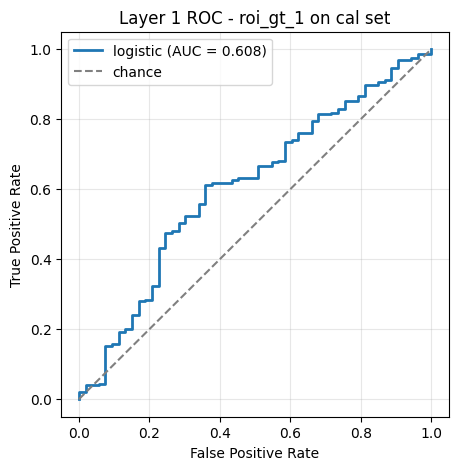

In [27]:
fpr, tpr, _ = roc_curve(y_cal, cal_proba_uncal)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"{CONFIG['model_family']} (AUC = {cal_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "--", color="grey", label="chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"Layer 1 ROC - {CONFIG['target']} on cal set")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# 3. Calibrate the probability outputs (Layer 2)

A model's `predict_proba` doesn't always mean what it
literally says. ``CalibratedClassifierCV`` re-fits a small
post-hoc transformer (sigmoid or isotonic) so the predicted
0.7 actually corresponds to a ~70% empirical positive rate.

We measure ECE (Expected Calibration Error) before vs after.
Lower is better; 0 = perfect.

In [28]:
def ece(y_true, y_prob, n_bins=10):
    edges = np.quantile(y_prob, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = 0.0, 1.0
    edges = np.maximum.accumulate(edges)
    bin_idx = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
    tot = 0.0
    for b in range(n_bins):
        m = bin_idx == b
        if m.any():
            tot += m.mean() * abs(y_prob[m].mean() - y_true[m].mean())
    return float(tot)

ece_uncal   = ece(y_cal, cal_proba_uncal)
brier_uncal = brier_score_loss(y_cal, cal_proba_uncal)
print(f"BEFORE calibration: ECE = {ece_uncal:.4f}, Brier = {brier_uncal:.4f}")

calibrator = CalibratedClassifierCV(
    FrozenEstimator(held_out_model),
    method=CONFIG["calibration_method"], cv=5,
)
calibrator.fit(X_cal, y_cal)
cal_proba = calibrator.predict_proba(X_cal)[:, 1]
ece_cal   = ece(y_cal, cal_proba)
brier_cal = brier_score_loss(y_cal, cal_proba)
print(f"AFTER  calibration: ECE = {ece_cal:.4f}, Brier = {brier_cal:.4f}")

BEFORE calibration: ECE = 0.2675, Brier = 0.2382
AFTER  calibration: ECE = 0.0000, Brier = 0.1550


### Reliability diagram

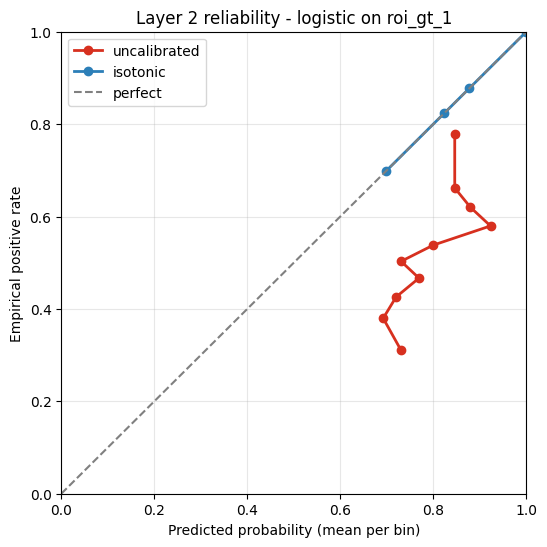

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
for label, p, color in [("uncalibrated", cal_proba_uncal, "#d7301f"),
                         (CONFIG["calibration_method"], cal_proba, "#2c7fb8")]:
    mp, fp = calibration_curve(y_cal, p, n_bins=10, strategy="quantile")
    ax.plot(mp, fp, marker="o", linewidth=2, color=color, label=label)
ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect")
ax.set_xlabel("Predicted probability (mean per bin)")
ax.set_ylabel("Empirical positive rate")
ax.set_title(f"Layer 2 reliability - {CONFIG['model_family']} on {CONFIG['target']}")
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); plt.show()

# 4. Apply the cost matrix (Layer 3)

For each calibrated probability ``p``, expected cost of each
action:

- Greenlight: ``(1 - p) * flop_cost``
- Pass:       ``p * miss_cost``
- Refer:      ``refer_cost`` (independent of p)

Pick the lowest-expected-cost action; tie-break to Refer.

In [30]:
def decide(p, fc, mc, rc):
    costs = {"Greenlight": (1 - p) * fc, "Pass": p * mc, "Refer": rc}
    mn = min(costs.values())
    return ("Refer" if costs["Refer"] == mn else min(costs, key=costs.get)), costs

actions, all_costs = zip(*[decide(p, CONFIG["flop_cost"],
                                  CONFIG["miss_cost"], CONFIG["refer_cost"])
                            for p in cal_proba])
actions = np.array(actions)
for a in ["Greenlight", "Pass", "Refer"]:
    print(f"  {a:11s}: {(actions == a).mean()*100:5.1f}%  ({(actions == a).sum():>3d} films)")

  Greenlight :   1.6%  (  4 films)
  Pass       :   0.0%  (  0 films)
  Refer      :  98.4%  (253 films)


### System total cost vs five baselines

In [31]:
def realized(action, true, fc, mc, rc):
    if action == "Greenlight": return 0 if true == 1 else fc
    if action == "Pass":       return mc if true == 1 else 0
    return rc

rng = np.random.default_rng(CONFIG["random_seed"])
baselines = {
    "Always-Greenlight": ["Greenlight"] * len(y_cal),
    "Always-Pass":       ["Pass"] * len(y_cal),
    "Read-Everything":   ["Refer"] * len(y_cal),
    "Random":            rng.choice(["Greenlight", "Pass", "Refer"], size=len(y_cal)).tolist(),
    "System (you!)":     actions.tolist(),
}
rows = []
for name, acts in baselines.items():
    tot = sum(realized(a, t, CONFIG["flop_cost"], CONFIG["miss_cost"], CONFIG["refer_cost"])
               for a, t in zip(acts, y_cal))
    rows.append({"strategy": name, "total_cost_USD": tot,
                 "cost_per_film_M": tot / len(y_cal) / 1e6})
bench = pd.DataFrame(rows).sort_values("total_cost_USD")
print(bench.to_string(index=False))

         strategy  total_cost_USD  cost_per_film_M
    System (you!)         1265000         0.004922
  Read-Everything         1285000         0.005000
Always-Greenlight      2650000000        10.311284
           Random      7750440000        30.157354
      Always-Pass     20400000000        79.377432


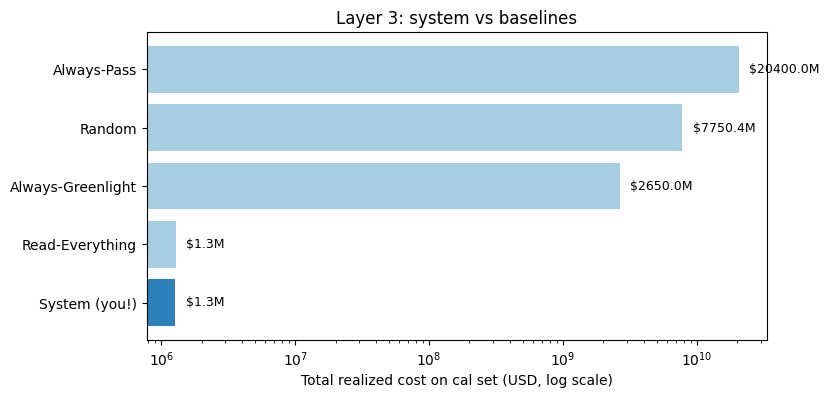

In [32]:
sb = bench.sort_values("total_cost_USD", ascending=True)
colors = ["#2c7fb8" if s == "System (you!)" else "#a6cee3" for s in sb["strategy"]]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(sb["strategy"], sb["total_cost_USD"].clip(lower=1), color=colors)
ax.set_xscale("log")
ax.set_xlabel("Total realized cost on cal set (USD, log scale)")
ax.set_title("Layer 3: system vs baselines")
for s, v in zip(sb["strategy"], sb["total_cost_USD"]):
    ax.text(max(v, 1) * 1.2, s, f"${v/1e6:.1f}M" if v >= 1e6 else f"${v/1e3:.0f}K",
            va="center", fontsize=9)
plt.show()

### Per-film recommendations (preview)

In [33]:
master_lookup = master.set_index("imdb_id")["movie_name"].to_dict()
decisions_df = pd.DataFrame({
    "imdb_id":                ids_cal,
    "movie_name":             [master_lookup.get(i, i) for i in ids_cal],
    "calibrated_probability": cal_proba,
    "true_label":             y_cal,
    "recommended_action":     actions,
})
decisions_df.to_csv(STUDENT / "student_decisions.csv", index=False)
print(f"Saved {STUDENT / 'student_decisions.csv'}: {len(decisions_df)} rows\n")
gl = decisions_df[decisions_df["recommended_action"] == "Greenlight"].head(8)
if len(gl):
    print("Greenlight films (preview, first 8):")
    print(gl[["movie_name", "calibrated_probability", "true_label"]].to_string(index=False))
else:
    print("System recommends 0 Greenlights on the cal set under this cost matrix.")

Saved /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project/data/processed/student/team_baseline_rf/student_decisions.csv: 257 rows

Greenlight films (preview, first 8):
              movie_name  calibrated_probability  true_label
          Evil Dead_2013                     1.0           1
The Matrix Reloaded_2003                     1.0           1
       3:10 to Yuma_2007                     1.0           1
             Haider_2014                     1.0           1


# 5. SHAP attribution (Layer 4)

TreeSHAP for tree models (xgboost, random_forest); for
logistic we use coefficient * feature_value. SVM-RBF
falls back to permutation importance.

Outputs:
- Global feature ranking by mean |contribution|
- Per-film breakdown for one example film

In [34]:
family = CONFIG["model_family"]

def attribute(pipe, X, family):
    scaler = pipe.named_steps["scaler"]
    clf = pipe.named_steps["model"]
    X_scaled = scaler.transform(X)
    if family in ("xgboost", "random_forest"):
        if not HAS_SHAP:
            raise RuntimeError("shap not installed. pip install shap")
        explainer = shap.TreeExplainer(clf)
        arr = np.asarray(explainer.shap_values(X_scaled))
        if arr.ndim == 3:
            arr = arr[:, :, 1]
        return arr, "TreeSHAP"
    if family == "logistic":
        coefs = clf.coef_.ravel()
        return X_scaled * coefs[np.newaxis, :], "linear coefficients * x"
    if family == "svm_rbf":
        from sklearn.inspection import permutation_importance
        pi = permutation_importance(pipe, X, pipe.predict(X), n_repeats=5,
                                      random_state=42, n_jobs=-1)
        return np.tile(pi.importances_mean, (len(X), 1)), "permutation importance"
    raise ValueError(family)

contribs, method = attribute(held_out_model, X_cal, family)
print(f"Attribution method: {method}")
print(f"Per-film contribution matrix shape: {contribs.shape}")

Attribution method: linear coefficients * x
Per-film contribution matrix shape: (257, 127)


### Global feature ranking

                      feature  mean_abs  mean_signed
          release_year_parsed   20.2218     -20.2218
                  log_runtime    2.3778       2.3778
       log_total_action_chars    1.1685      -1.1685
         log_n_dialogue_lines    0.8431      -0.8431
           mean_log_frequency    0.8142       0.8142
         vader_compound_range    0.4744      -0.4744
     log_total_dialogue_chars    0.4362      -0.4362
         hapax_ratio_dialogue    0.4332       0.4332
      network_lead_role_count    0.4325      -0.4325
first_to_second_pronoun_ratio    0.3614       0.3614
  network_top3_dialogue_share    0.3564       0.3564
        network_dialogue_gini    0.2990       0.2990
                  mtld_action    0.2560      -0.2560
          nrc_fear_proportion    0.2513      -0.2513
  topic_concentration_entropy    0.2260      -0.2260


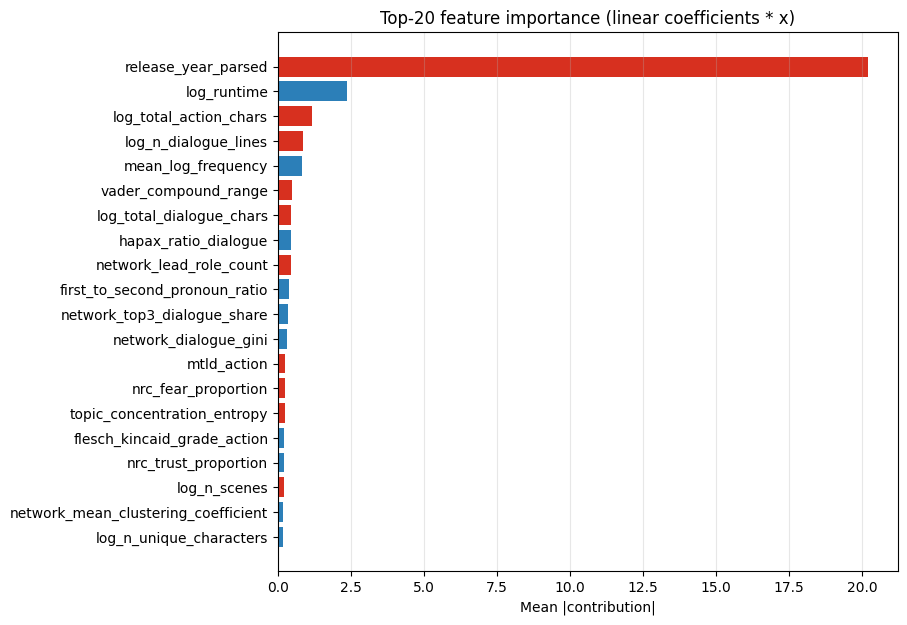

Blue = pushes probability UP on average; Red = pulls DOWN


In [35]:
ranking = pd.DataFrame({
    "feature":     feat_cols,
    "mean_abs":    np.mean(np.abs(contribs), axis=0),
    "mean_signed": np.mean(contribs, axis=0),
}).sort_values("mean_abs", ascending=False).reset_index(drop=True)

K = CONFIG["shap_top_k_global"]
print(ranking.head(15).round(4).to_string(index=False))

top = ranking.head(K).iloc[::-1]
colors = ["#2c7fb8" if s >= 0 else "#d7301f" for s in top["mean_signed"]]
fig, ax = plt.subplots(figsize=(8, K * 0.3 + 1))
ax.barh(top["feature"], top["mean_abs"], color=colors)
ax.set_xlabel("Mean |contribution|")
ax.set_title(f"Top-{K} feature importance ({method})")
ax.grid(axis="x", alpha=0.3); plt.show()
print("Blue = pushes probability UP on average; Red = pulls DOWN")

### Per-film breakdown for one example

Inspecting: Evil Dead_2013 (tt1288558) | predicted P = 1.000


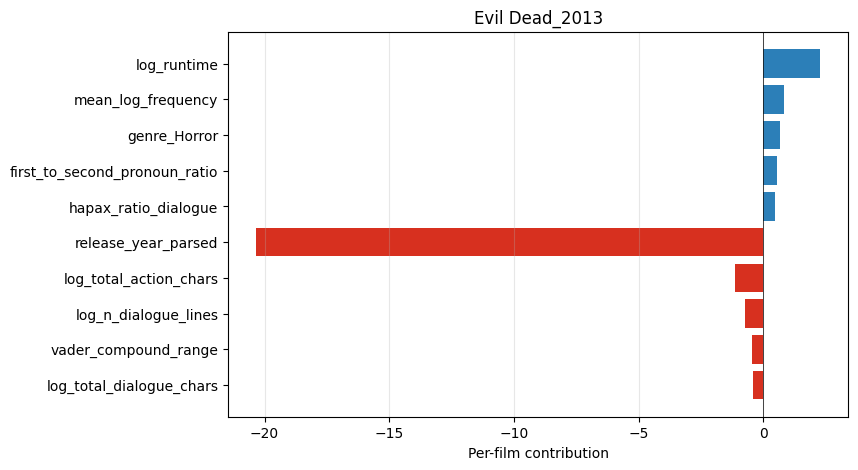

In [36]:
if CONFIG["shap_example_imdb_id"] == "auto":
    ex_idx = int(np.argmax(cal_proba))
    ex_id = ids_cal[ex_idx]
else:
    ex_id = CONFIG["shap_example_imdb_id"]
    ex_idx = ids_cal.index(ex_id)
movie = master_lookup.get(ex_id, ex_id)
print(f"Inspecting: {movie} ({ex_id}) | predicted P = {cal_proba[ex_idx]:.3f}")

K2 = CONFIG["shap_top_k_per_film"]
film = pd.DataFrame({"feature": feat_cols, "contribution": contribs[ex_idx]})
top_pos = film[film["contribution"] > 0].nlargest(K2, "contribution")
top_neg = film[film["contribution"] < 0].nsmallest(K2, "contribution")
show = pd.concat([top_pos, top_neg]).iloc[::-1]
colors = ["#2c7fb8" if v >= 0 else "#d7301f" for v in show["contribution"]]
fig, ax = plt.subplots(figsize=(8, len(show) * 0.4 + 1))
ax.barh(show["feature"], show["contribution"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Per-film contribution"); ax.set_title(f"{movie}")
ax.grid(axis="x", alpha=0.3); plt.show()

# 6. Save the run bundle

Everything trained and computed above goes into one joblib
file under your run_name's folder. Useful for the team
comparison meeting.

In [37]:
bundle = {
    "config":          CONFIG,
    "feature_columns": feat_cols,
    "tuned_model":     tuned_model,
    "held_out_model":  held_out_model,
    "calibrator":      calibrator,
    "cv_auc_mean":     cv_auc_mean,
    "cv_auc_std":      cv_auc_std,
    "cal_auc":         float(cal_auc),
    "ece_uncalibrated": ece_uncal,
    "ece_calibrated":   ece_cal,
    "best_params":     str(best_params),
    "decisions_df":    decisions_df,
    "shap_ranking":    ranking,
}
joblib.dump(bundle, STUDENT / "student_full_pipeline.joblib")
print(f"Saved {STUDENT / 'student_full_pipeline.joblib'}")

Saved /Users/ChloeTabourian/Documents/University/AUB Grad/MSBA 315 - Predictive Analytics & Machine Learning/ML_Final_Project/data/processed/student/team_baseline_rf/student_full_pipeline.joblib


# 7. Test-set evaluation (gated)

**Only runs when ``CONFIG["EVALUATE_ON_TEST"]`` is True.**
Leave it False while you iterate on model choice. Flip to
True ONCE for the final number that goes in the report.

The test set is touched once across the whole project.

In [38]:
if not CONFIG["EVALUATE_ON_TEST"]:
    print("EVALUATE_ON_TEST=False -> skipping test-set evaluation.")
    print("Flip CONFIG['EVALUATE_ON_TEST']=True for the final report run.")
else:
    df_test = feat[feat["split"] == "test"].reset_index(drop=True)
    X_test = df_test[feat_cols].fillna(0).values
    y_test = df_test[target_col].astype(int).values
    ids_test = df_test["imdb_id"].astype(str).tolist()
    print(f"Test set: {len(df_test)} films, positive rate {y_test.mean():.3f}")

    # Calibrated probabilities on test.
    test_proba = calibrator.predict_proba(X_test)[:, 1]

    # Layer 1 metrics with bootstrap CIs.
    rng2 = np.random.default_rng(CONFIG["random_seed"])
    def boot_ci(metric, *args, n=2000):
        arrs = [np.asarray(a) for a in args]
        pt = float(metric(*arrs))
        samples = []
        for _ in range(n):
            idx = rng2.integers(0, len(arrs[0]), size=len(arrs[0]))
            try:    samples.append(float(metric(*[a[idx] for a in arrs])))
            except Exception: pass
        lo, hi = np.quantile(samples, [0.025, 0.975])
        return pt, lo, hi
    print("\n--- Layer 1: predictive performance on test ---")
    for name, fn in [
        ("AUC-ROC",  lambda y, p: roc_auc_score(y, p)),
        ("PR-AUC",   lambda y, p: average_precision_score(y, p)),
        ("F1@0.5",   lambda y, p: f1_score(y, (p >= 0.5).astype(int), zero_division=0)),
        ("log-loss", lambda y, p: log_loss(y, np.clip(p, 1e-7, 1-1e-7), labels=[0, 1])),
        ("Brier",    lambda y, p: brier_score_loss(y, p)),
    ]:
        pt, lo, hi = boot_ci(fn, y_test, test_proba)
        print(f"  {name:9s}: {pt:.3f} [{lo:.3f}, {hi:.3f}]")

    # Layer 2 calibration on test.
    print("\n--- Layer 2: calibration on test ---")
    print(f"  ECE on test:   {ece(y_test, test_proba):.4f}")
    print(f"  Brier on test: {brier_score_loss(y_test, test_proba):.4f}")

    # Layer 3 decisions + baselines on test.
    test_actions = [decide(p, CONFIG["flop_cost"], CONFIG["miss_cost"],
                            CONFIG["refer_cost"])[0] for p in test_proba]
    print("\n--- Layer 3: decisions on test ---")
    for a in ["Greenlight", "Pass", "Refer"]:
        print(f"  {a:11s}: {(np.array(test_actions) == a).mean()*100:5.1f}%")

    test_baselines = {
        "Always-Greenlight": ["Greenlight"] * len(y_test),
        "Always-Pass":       ["Pass"] * len(y_test),
        "Read-Everything":   ["Refer"] * len(y_test),
        "System (you!)":     test_actions,
    }
    test_rows = []
    for nm, acts in test_baselines.items():
        t = sum(realized(a, t_, CONFIG["flop_cost"], CONFIG["miss_cost"],
                          CONFIG["refer_cost"]) for a, t_ in zip(acts, y_test))
        test_rows.append({"strategy": nm, "total_cost_M": t / 1e6})
    print("\n", pd.DataFrame(test_rows).sort_values("total_cost_M").to_string(index=False))

    # Save test predictions.
    test_report = pd.DataFrame({
        "imdb_id":                ids_test,
        "movie_name":             [master_lookup.get(i, i) for i in ids_test],
        "calibrated_probability": test_proba,
        "true_label":             y_test,
        "recommended_action":     test_actions,
    })
    test_report.to_csv(STUDENT / "student_test_predictions.csv", index=False)
    print(f"\nSaved {STUDENT / 'student_test_predictions.csv'}")

EVALUATE_ON_TEST=False -> skipping test-set evaluation.
Flip CONFIG['EVALUATE_ON_TEST']=True for the final report run.


# 8. Compare to your teammates

Copy your headline numbers into a shared table:

| Person | run_name | model_family | Tuned CV AUC | Cal AUC | ECE after | System cost (cal) |
|---|---|---|---|---|---|---|
| Alice | alice_xgboost | xgboost | … | … | … | … |
| Bob | bob_random_forest | random_forest | 0.612 | 0.614 | 0.0035 | … |

### Reference numbers (default RF + all 3 toggles ON)

| Stage | Value |
|---|---|
| Tuned CV AUC | 0.612 ± 0.022 |
| Held-out cal AUC | 0.614 |
| ECE before / after calibration | 0.344 / 0.0035 |
| Best RF params | max_depth=10, min_samples_leaf=10, n_estimators=500 |

### Bare baseline numbers (all 3 toggles OFF) for comparison

| model_family | CV AUC | Cal AUC |
|---|---|---|
| random_forest | 0.595 | 0.612 |
| xgboost       | 0.597 | 0.569 |
| logistic      | 0.576 | 0.573 |
| svm_rbf       | 0.571 | 0.530 |

### Rigorous Phase 4 reference (curated 92 features, full search)

| model_family | OOF AUC |
|---|---|
| xgboost | 0.652 |
| svm_rbf | 0.635 |

### Ablating the three toggles

Run with all three on (default), then flip one at a time to
False and see what each contributes:

- Off ``use_grid_search``: cal AUC drops ~0.01-0.02 for tree
  models. The single biggest knob.
- Off ``use_repeated_cv``: headline mean barely moves; only
  the CI gets wider.
- Off ``use_class_balance``: cal AUC drops ~0.005. Small but
  free.

That's it. One notebook, one CONFIG, end-to-end.